In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kmader_food41_path = kagglehub.dataset_download('kmader/food41')

print('Data source import complete.')

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report


In [ ]:
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
IMG_SIZE = (260, 260)
BATCH_SIZE = 16
EPOCHS_INITIAL = 10
EPOCHS_FINE = 25
SEED = 42

DATA_DIR = "/kaggle/input/food41/images"
CHECKPOINT_PATH = "/kaggle/working/best_effnetb3.keras"


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)


Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
Number of classes: 101


In [ ]:
def one_hot(image, label):
    label = tf.cast(label, tf.int32)
    return image, tf.one_hot(label, num_classes)

train_ds = train_ds.map(one_hot, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(one_hot, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.3),
])

In [ ]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(260, 260, 3)
)

base_model.trainable = False

In [ ]:
inputs = keras.Input(shape=(260, 260, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 9, 9, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │       155,237 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,944,916 (41.75 MB)

 Trainable params: 158,309 (618.39 KB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_INITIAL,
    callbacks=[checkpoint_cb, lr_cb]
)


Epoch 1/10


E0000 00:00:1766296567.380906      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3142 - loss: 3.6158
Epoch 1: val_accuracy improved from -inf to 0.60599, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 465s 89ms/step - accuracy: 0.3142 - loss: 3.6157 - val_accuracy: 0.6060 - val_loss: 2.1539 - learning_rate: 0.0010
Epoch 2/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4602 - loss: 2.7376
Epoch 2: val_accuracy improved from 0.60599 to 0.62856, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 442s 87ms/step - accuracy: 0.4602 - loss: 2.7376 - val_accuracy: 0.6286 - val_loss: 2.0678 - learning_rate: 0.0010
Epoch 3/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4860 - loss: 2.5822
Epoch 3: val_accuracy improved from 0.62856 to 0.63802, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 430s 85ms/step - accuracy: 0.4860 - loss: 2.5822 - val_accuracy: 0.6380 - val_loss: 2.0343 - learnin

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-120]:
    layer.trainable = False


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=[checkpoint_cb, lr_cb]
)


Epoch 1/25


E0000 00:00:1766300936.066621      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5412 - loss: 2.3932
Epoch 1: val_accuracy improved from 0.65436 to 0.75619, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 678s 129ms/step - accuracy: 0.5412 - loss: 2.3931 - val_accuracy: 0.7562 - val_loss: 1.6804 - learning_rate: 1.0000e-04
Epoch 2/25
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6861 - loss: 1.9008
Epoch 2: val_accuracy improved from 0.75619 to 0.78322, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 648s 128ms/step - accuracy: 0.6861 - loss: 1.9007 - val_accuracy: 0.7832 - val_loss: 1.5753 - learning_rate: 1.0000e-04
Epoch 3/25
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7377 - loss: 1.7328
Epoch 3: val_accuracy improved from 0.78322 to 0.79614, saving model to /kaggle/working/best_effnetb3.keras
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 647s 128ms/step - accuracy: 0.7377 - loss: 1.7328 - val_accuracy: 0.7961 - val_loss:

In [ ]:
model = keras.models.load_model(CHECKPOINT_PATH)


In [ ]:
loss, acc = model.evaluate(val_ds)
print(f" Validation Accuracy: {acc:.4f}")


1263/1263 ━━━━━━━━━━━━━━━━━━━━ 91s 67ms/step - accuracy: 0.8274 - loss: 1.4084
 Validation Accuracy: 0.8281


In [ ]:
from tensorflow import keras

model = keras.models.load_model("/kaggle/working/best_effnetb3.keras")
print("✅ Loaded best checkpoint")


✅ Loaded best checkpoint


In [ ]:
model = keras.models.load_model("/kaggle/working/best_effnetb3.keras")


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-60]:
    layer.trainable = False


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [ ]:
history_more = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_cb, lr_cb]
)


Epoch 1/10


E0000 00:00:1766317216.408236      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9628 - loss: 0.9887
Epoch 1: val_accuracy did not improve from 0.82807
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 670s 127ms/step - accuracy: 0.9628 - loss: 0.9887 - val_accuracy: 0.8275 - val_loss: 1.4134 - learning_rate: 1.0000e-05
Epoch 2/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9621 - loss: 0.9873
Epoch 2: val_accuracy did not improve from 0.82807
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 640s 127ms/step - accuracy: 0.9621 - loss: 0.9873 - val_accuracy: 0.8270 - val_loss: 1.4140 - learning_rate: 1.0000e-05
Epoch 3/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9635 - loss: 0.9807
Epoch 3: val_accuracy did not improve from 0.82807
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 648s 128ms/step - accuracy: 0.9635 - loss: 0.9807 - val_accuracy: 0.8264 - val_loss: 1.4157 - learning_rate: 1.0000e-05
Epoch 4/10
5050/5050 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9660 - loss: 0.9768
Epoch 4: val_accuracy did not improve from 0.

In [ ]:
model = keras.models.load_model("/kaggle/working/best_effnetb3.keras")

loss, acc = model.evaluate(val_ds)
print(f"Improved Validation Accuracy: {acc:.4f}")


1263/1263 ━━━━━━━━━━━━━━━━━━━━ 93s 68ms/step - accuracy: 0.8280 - loss: 1.4071
Improved Validation Accuracy: 0.8281


In [ ]:
from tensorflow import keras

MODEL_PATH = "/kaggle/working/best_effnetb3.keras"
model = keras.models.load_model(MODEL_PATH)

print("✅ Model loaded")


✅ Model loaded


In [ ]:
import tensorflow as tf

DATA_DIR = "/kaggle/input/food41/images"
IMG_SIZE = (260, 260)
SEED = 42

tmp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=16
)

class_names = tmp_ds.class_names
print("Classes:", len(class_names))


Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
Classes: 101


In [ ]:
from IPython.display import display
import ipywidgets as widgets

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)


FileUpload(value=(), accept='image/*', description='Upload')

In [ ]:
import numpy as np
from PIL import Image
import io
import tensorflow as tf
from IPython.display import display

def predict_uploaded_image(uploader):
    if uploader.value is None or len(uploader.value) == 0:
        print("❌ Please upload an image first.")
        return

    # ✅ Handle BOTH dict and tuple formats
    if isinstance(uploader.value, dict):
        file_info = list(uploader.value.values())[0]
    else:  # tuple
        file_info = uploader.value[0]

    image_bytes = file_info["content"]

    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img = img.resize(IMG_SIZE)

    img_array = np.array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)[0]
    idx = np.argmax(preds)

    display(img)
    print(f"🍽️ Predicted Food: {class_names[idx]}")
    print(f"🔍 Confidence: {preds[idx]*100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


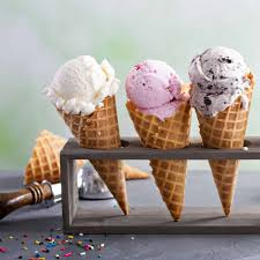

🍽️ Predicted Food: ice_cream
🔍 Confidence: 69.84%


In [ ]:
predict_uploaded_image(uploader)


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=5, name="top_5_accuracy")
    ]
)


In [ ]:
results = model.evaluate(val_ds, verbose=1)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")


1263/1263 ━━━━━━━━━━━━━━━━━━━━ 92s 68ms/step - accuracy: 0.8275 - loss: 1.4090 - top_5_accuracy: 0.9446
loss: 1.4127
compile_metrics: 0.8281


In [ ]:
loss, top1, top5 = model.evaluate(val_ds, verbose=0)

print(f"Validation Top-1 Accuracy : {top1*100:.2f}%")
print(f"Validation Top-5 Accuracy : {top5*100:.2f}%")


Validation Top-1 Accuracy : 82.81%
Validation Top-5 Accuracy : 94.52%


In [ ]:
from IPython.display import FileLink
FileLink("/kaggle/working/best_effnetb3.keras")


/kaggle/working/best_effnetb3.keras

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)


Confusion matrix shape: (101, 101)


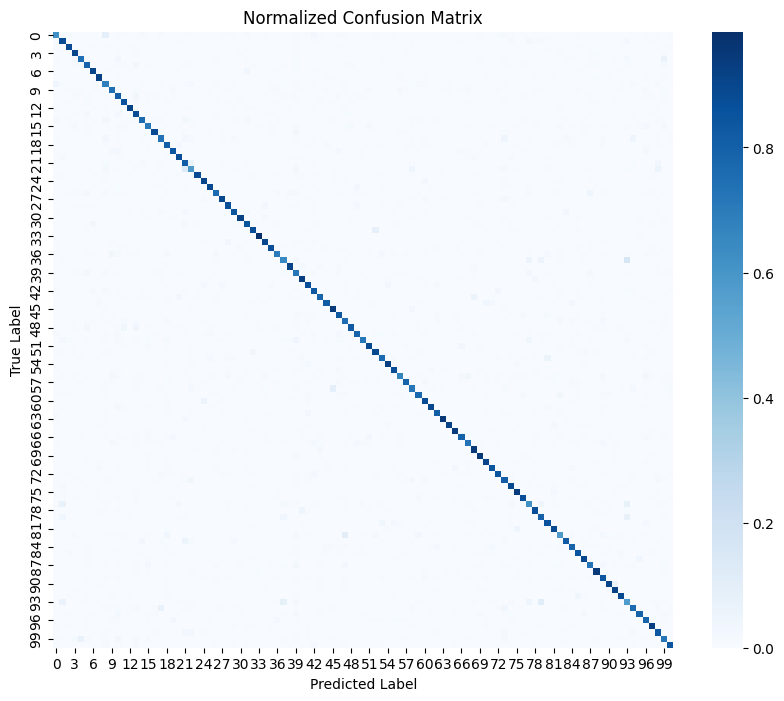

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    cbar=True
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
from tensorflow.keras.metrics import CategoricalAccuracy, TopKCategoricalAccuracy

top1 = CategoricalAccuracy()
top5 = TopKCategoricalAccuracy(k=5)

for images, labels in val_ds:
    preds = model(images, training=False)
    top1.update_state(labels, preds)
    top5.update_state(labels, preds)

print(f"Validation Top-1 Accuracy : {top1.result().numpy()*100:.2f}%")
print(f"Validation Top-5 Accuracy : {top5.result().numpy()*100:.2f}%")


Validation Top-1 Accuracy : 82.81%
Validation Top-5 Accuracy : 94.52%
